# Detection of Chagas Disease from the ECG: PhysioNet Challenge 2025
## Authors

- Matteo Fasulo 

- Antonio Gravina 

- Luca Babboni 

### Chagas Disease Overview  



- **Cause & Transmission**: Caused by *Trypanosoma cruzi*, primarily spread by **triatomine insects**, but also through **blood transfusions, organ transplants, and congenital transmission**.  



- **Disease Progression**: Two phases—**acute (mild/nonspecific symptoms)** and **chronic (asymptomatic in most, but 30-40% develop severe complications, mainly cardiac)**. **Early antiparasitic treatment is effective**, but loses efficacy as the infection progresses.  



- **Historical Background**: **Named after Carlos Chagas**, who discovered it in 1909. Chronic complications, especially **cardiac and digestive issues**, typically appear **10 to 30 years** post-infection.  



- **Diagnosis**: Detected via **blood tests (parasite detection or serological tests for antibodies)**.  



- **Cardiac Impact & ECG Role**: **Chagas cardiomyopathy** can cause **heart damage, arrhythmias, conduction disorders, and dilated cardiomyopathy**. **Severe cases may lead to sudden cardiac death**, though the **indeterminate chronic form lacks ECG abnormalities**, making early detection challenging.

### About the Challenge  



- The **George B. Moody PhysioNet Challenge 2025** [[1]](https://moody-challenge.physionet.org/2025/) is a **prestigious annual competition** focused on advancing **physiological and clinical problem-solving**.  



- This year’s challenge targets **Chagas disease**, a **serious cardiovascular threat** prevalent in **Central and South America**.  



- Participants must develop **open-source algorithms** to **detect Chagas disease** using **standard 12-lead ECGs**.  



- The goal is to **improve screening efficiency**, identifying **potential cases for confirmatory serological testing** while optimizing healthcare resources.  



- Inspired by this, our objective is to build a model that can **accurately detect Chagas disease using only a short (~10-second) 12-lead ECG recording**.  

In [48]:
import gc
import warnings
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sn
import scipy as sp
import numpy as np
import pandas as pd
import neurokit2 as nk
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import *
from sklearn.inspection import permutation_importance
import xgboost
import shap
from boruta import BorutaPy
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchview import draw_graph
import optuna
import os
import sys
import glob
import orjson
import pywt
import logging


module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    sys.path.append(os.path.abspath(os.path.join(module_path, 'official')))

import wfdb
from helper_code import *
# import utils

# --- Setup ---
%matplotlib inline
figsize=(14, 4)
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
warnings.filterwarnings("ignore")
logging.basicConfig(filename='eda_errors.log', level=logging.ERROR,
                    format='%(asctime)s - %(levelname)s - %(message)s')

### Dataset  
- The **2025 PhysioNet Challenge** uses the **CODE-15% Database** [[2]](https://zenodo.org/records/4916206), which contains **300,000+ 12-lead ECG recordings** collected in **Brazil (2010–2016)**.  
- **Binary Chagas disease labels** are included, based on **self-reported diagnoses** and potentially supplemented by questionnaire responses.  
- Each ECG record has a **WFDB header file** with metadata such as **sampling frequency, signal parameters, demographics (if available), and Chagas labels**.  
- Example: **Record 113** contains **12 channels, 400 Hz sampling frequency, and 4096 samples per channel**.  

### Feature Extraction & Data Processing

In [49]:
def extract_basic_features(record_path):
    """
    Extracts basic demographic and clinical features from the header file.
    """
    try:
        header = load_header(record_path + '.hea')
        age = get_age(header)
        is_male = 1 if get_sex(header) == 'Male' else 0
        chagas = get_label(header)
        return {'age': age, 'is_male': is_male, 'chagas': chagas}
    except Exception as e:
        logging.warning(f"Could not extract basic features from {record_path}.hea: {e}")
        return None

def extract_wavelet_features(record_path):
    """
    Extracts wavelet-based features from the ECG signal.
    """
    try:
        signals, _ = wfdb.rdsamp(record_path)
        ecg_signal = signals[:, 0]

        # Wavelet decomposition
        coeffs = pywt.wavedec(ecg_signal, 'db4', level=4)
        cA4, cD4, cD3, cD2, cD1 = coeffs

        features = {
            'wavelet_energy_d1': np.sum(np.square(cD1)),
            'wavelet_energy_d2': np.sum(np.square(cD2)),
            'wavelet_energy_d3': np.sum(np.square(cD3)),
            'wavelet_energy_d4': np.sum(np.square(cD4)),
            'wavelet_energy_a4': np.sum(np.square(cA4)),
            'wavelet_std_d1': np.std(cD1),
            'wavelet_std_d2': np.std(cD2),
            'wavelet_std_d3': np.std(cD3),
            'wavelet_std_d4': np.std(cD4),
            'wavelet_std_a4': np.std(cA4),
        }
        return features
    except Exception as e:
        logging.warning(f"Could not extract wavelet features from {record_path}: {e}")
        return None

def extract_advanced_ecg_features(signal, sampling_rate):
    """
    Extracts morphological and HRV features from a single ECG signal.
    Focuses on features robust for short recordings.
    """
    features = {}
    if signal.ndim > 1 and signal.shape[1] > 1:
        lead_signal = signal[:, 1]
    else:
        lead_signal = signal.flatten()

    try:
        signals, info = nk.ecg_process(lead_signal, sampling_rate=sampling_rate)
        peaks = info["ECG_R_Peaks"]

        if len(peaks) < 4: 
            return {}, []

        morph_features = [
            'ECG_P_Duration', 'ECG_P_Amplitude', 'ECG_QRS_Duration', 
            'ECG_QRS_Amplitude', 'ECG_T_Duration', 'ECG_T_Amplitude', 'ECG_QT_Interval'
        ]
        for feature in morph_features:
            if feature in signals:
                feature_values = signals[feature].dropna()
                if not feature_values.empty:
                    features[f'{feature}_mean'] = feature_values.mean()
                    features[f'{feature}_std'] = feature_values.std()
                else:
                    features[f'{feature}_mean'] = np.nan
                    features[f'{feature}_std'] = np.nan

        if len(peaks) > 20:
            try:
                if np.std(np.diff(peaks)) > 0:
                    hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=False)
                    features['HRV_RMSSD'] = hrv_time['HRV_RMSSD'].iloc[0]
                    features['HRV_MeanNN'] = hrv_time['HRV_MeanNN'].iloc[0]
                    features['HRV_pNN50'] = hrv_time['HRV_pNN50'].iloc[0]
                    hrv_poincare_df = nk.hrv_poincare(peaks, sampling_rate=sampling_rate, show=False)
                    features['HRV_SD1'] = hrv_poincare_df['HRV_SD1'].iloc[0]
                else:
                    raise ValueError("No variability in RR-intervals.")
            except Exception:
                features['HRV_RMSSD'] = np.nan
                features['HRV_MeanNN'] = np.nan
                features['HRV_pNN50'] = np.nan
                features['HRV_SD1'] = np.nan
        else:
            features['HRV_RMSSD'] = np.nan
            features['HRV_MeanNN'] = np.nan
            features['HRV_pNN50'] = np.nan
            features['HRV_SD1'] = np.nan

        if 'ECG_Rate' in signals and not signals['ECG_Rate'].dropna().empty:
            features['Heart_Rate_Mean'] = signals['ECG_Rate'].mean()
        else:
            features['Heart_Rate_Mean'] = np.nan
        
        rr_interval_lengths = [len(peaks)]

    except Exception as e:
        logging.warning(f"Could not process advanced features for a signal due to: {e}")
        return {}, []

    return features, rr_interval_lengths

def process_record(record_path):
    """
    Main processing function for a single record.
    """
    try:
        basic_features = extract_basic_features(record_path)
        if not basic_features:
            return None, []

        signal, fields = wfdb.rdsamp(record_path)
        sampling_rate = fields['fs']
        
        if signal is None or signal.size == 0:
            return None, []

        advanced_features, rr_interval_lengths = extract_advanced_ecg_features(signal, sampling_rate)
        wavelet_features = extract_wavelet_features(record_path)

        all_features = basic_features
        if advanced_features:
            all_features.update(advanced_features)
        if wavelet_features:
            all_features.update(wavelet_features)
        
        all_features['record'] = os.path.basename(record_path)
        return all_features, rr_interval_lengths
    except Exception as e:
        logging.error(f"Failed to process record {os.path.basename(record_path)}: {e}")
        return None, []

In [ ]:
data_dir = '../training_data/samitrop/'
print(os.getcwd())
print(f"Searching for .hea files in: {data_dir}")

hea_files = glob.glob(os.path.join(data_dir, '**', '*.hea'), recursive=True)
record_stems = [f[:-4] for f in hea_files]
print(f"Found {len(record_stems)} records to process.")

all_rr_interval_lengths_collected = []
processed_results = []

with Parallel(n_jobs=-1) as parallel:
    for res, rr_lengths in tqdm(parallel(delayed(process_record)(record) for record in record_stems), total=len(record_stems)):
        if res is not None:
            processed_results.append(res)
            if rr_lengths:
                all_rr_interval_lengths_collected.extend(rr_lengths)

df = pd.DataFrame(processed_results)
df.dropna(subset=['chagas'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("Feature extraction complete.")
print(f"Dataset shape: {df.shape}")

/Users/andysmithwick/Documents/GitHub/physionet2025/EDA
Searching for .hea files in: ../training_data/samitrop/
Found 815 records to process.


/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: divide by zero encountered in divide
  mrrs /= th2
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/neurokit2/signal/signal_fixpeaks.py:307: RuntimeWarning: invalid value encountered in divide
  mrrs /= th2
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning 

# Exploratory Data Analysis

In [ ]:
df.chagas.value_counts(normalize=True)

chagas
1    1.0
Name: proportion, dtype: float64

In [ ]:
df['is_male'] = df['is_male'].astype(int)
df['chagas'] = df['chagas'].astype(int)

In [ ]:
num_cols = [c for c in df.columns if df[c].dtype != 'object' and df[c].nunique() > 2]
cat_cols = [c for c in df.columns if df[c].dtype != 'object' and df[c].nunique() == 2]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

Numeric: ['age', 'Heart_Rate_Mean', 'wavelet_energy_d1', 'wavelet_energy_d2', 'wavelet_energy_d3', 'wavelet_energy_d4', 'wavelet_energy_a4', 'wavelet_std_d1', 'wavelet_std_d2', 'wavelet_std_d3', 'wavelet_std_d4', 'wavelet_std_a4']
Total: 12
Categorical: ['is_male']
Total: 1


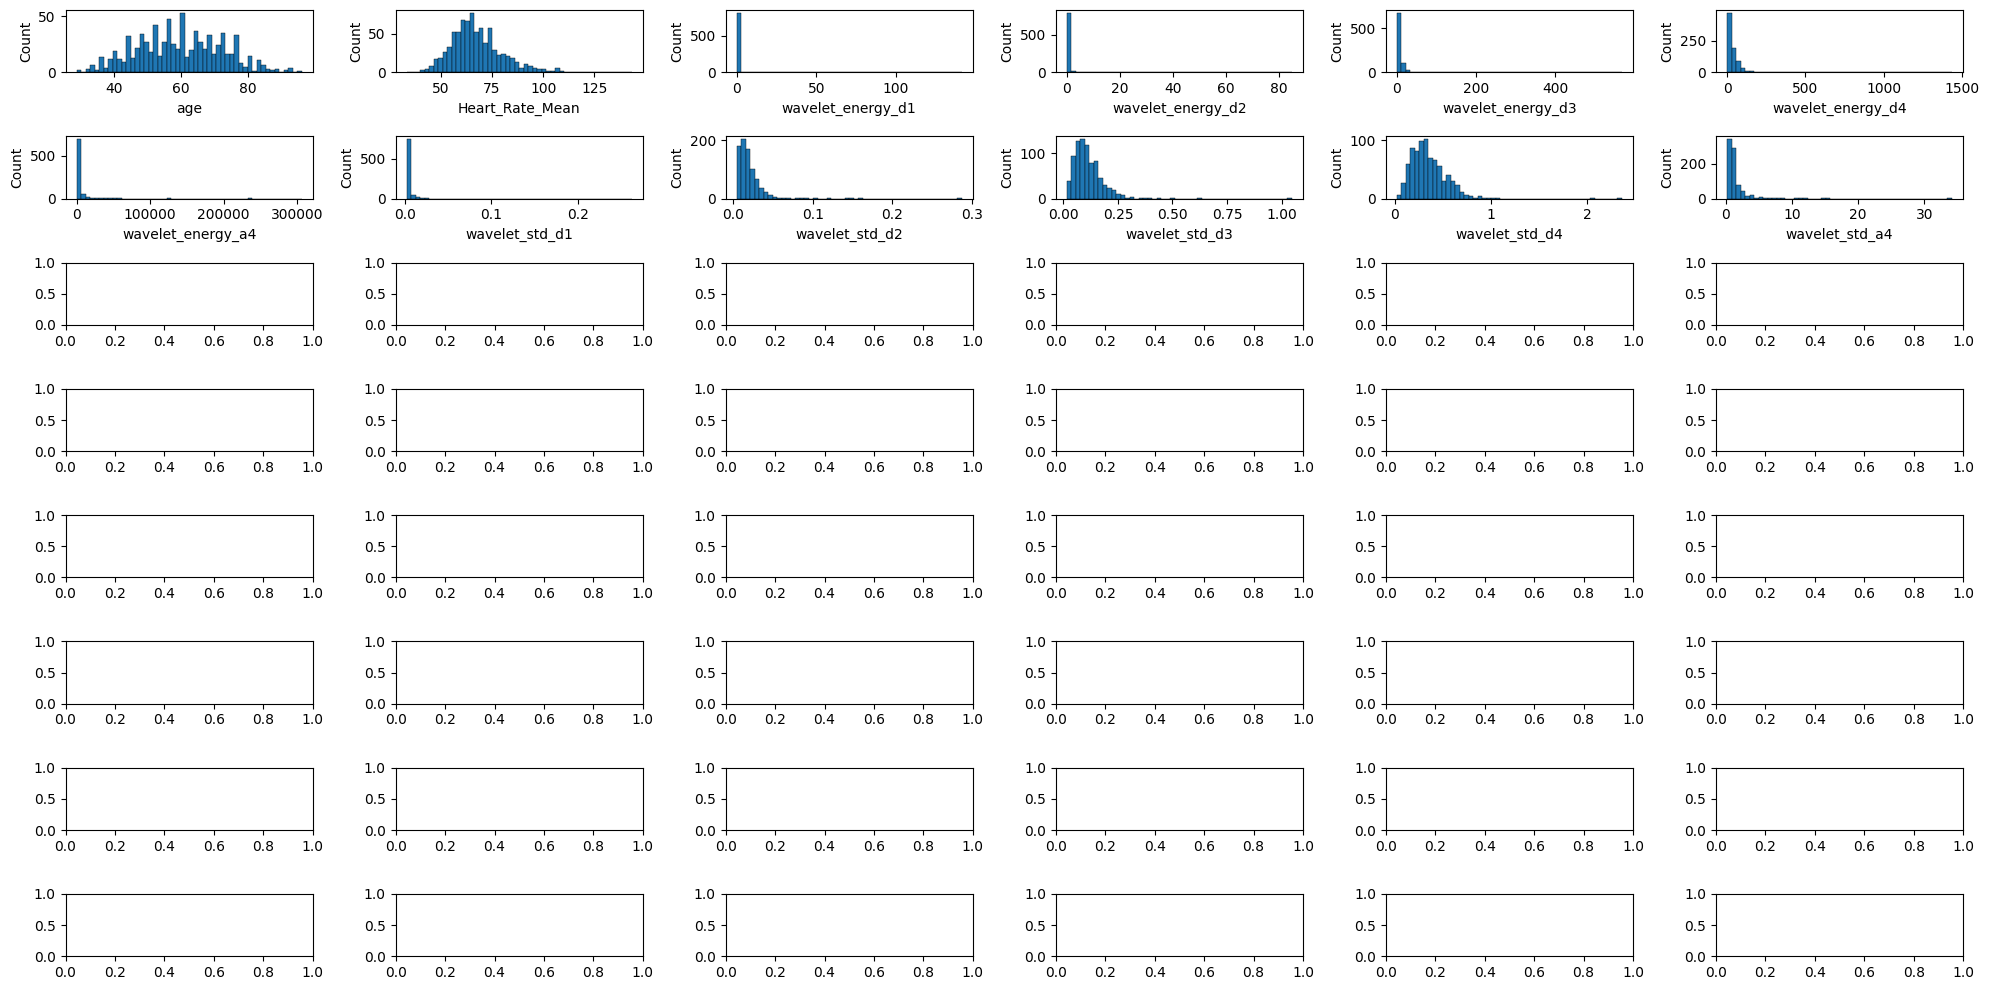

In [ ]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    sn.histplot(data=df, x=cname, bins=50, stat="count", alpha=1, kde=False, multiple='dodge', ax=ax, hue='chagas', legend=False)
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_columns', None)
with_chagas = df[df['chagas'] == 1]
without_chagas = df[df['chagas'] == 0]

t_test_df = pd.DataFrame(columns=['column', 't_stat', 'p_value', 'is_significant'])
for col in num_cols:
    if col != 'chagas':
        test_result = sp.stats.ttest_ind(with_chagas[col].dropna(), without_chagas[col].dropna(), equal_var=False)
        t_test_df.loc[len(t_test_df)] = [col, test_result[0], test_result[1], test_result[1] < 0.05]
t_test_df.sort_values(by='p_value')

,column,t_stat,p_value,is_significant
0,age,NaN,NaN,False
1,Heart_Rate_Mean,NaN,NaN,False
2,wavelet_energy_d1,NaN,NaN,False
3,wavelet_energy_d2,NaN,NaN,False
4,wavelet_energy_d3,NaN,NaN,False
5,wavelet_energy_d4,NaN,NaN,False
6,wavelet_energy_a4,NaN,NaN,False
7,wavelet_std_d1,NaN,NaN,False
8,wavelet_std_d2,NaN,NaN,False
9,wavelet_std_d3,NaN,NaN,False


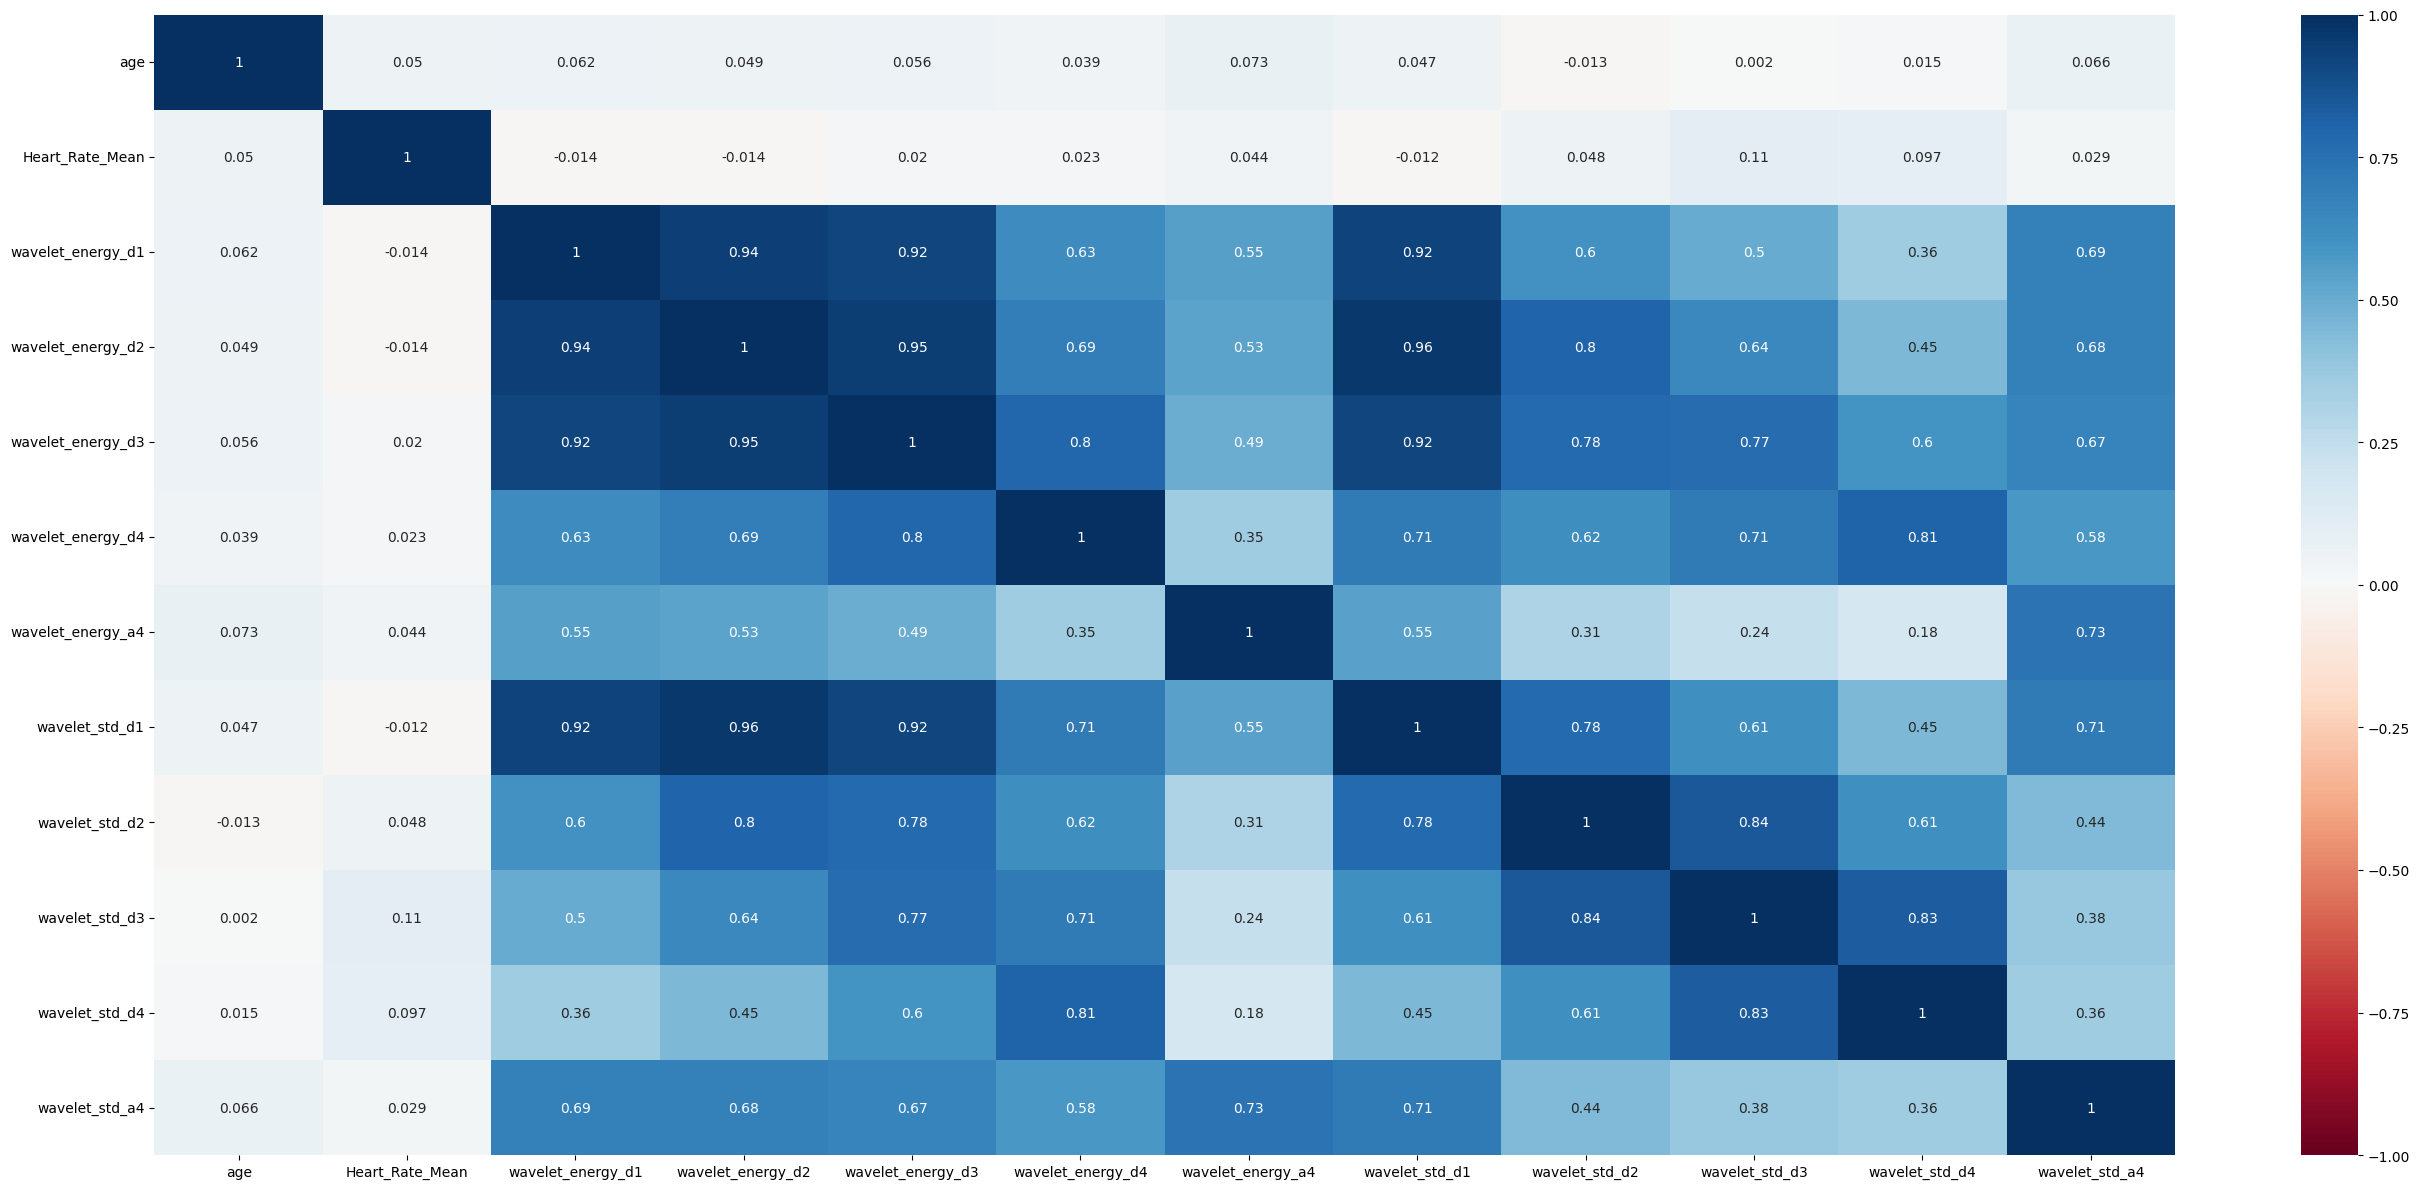

In [ ]:
plt.figure(figsize=(27,12))
sn.heatmap(df[num_cols].corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

## A more in-depth analysis of the data

UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

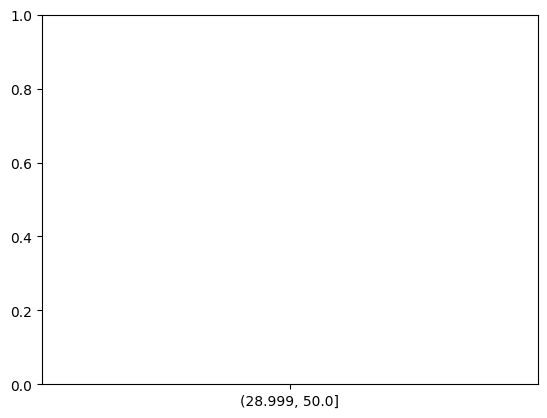

In [ ]:
# df['age_group'] = pd.qcut(df['age'], q=4)
# # boxprops = dict(edgecolor='k', linewidth=1.5)
# sn.boxplot(
#     x='age_group',
#     y='HRV_MeanNN',
#     hue='chagas',
#     data=df,
#     showfliers=False,
#     showmeans=True,
# )

# plt.tight_layout()
# plt.show()

### Standardization of the data

In [ ]:
X, y = df.drop(columns=['chagas', 'age_group', 'record'], axis=1), df['chagas']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y, shuffle=True)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
results_dict = {}

def print_results(model, y_test, y_pred, y_pred_proba):
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    f_beta = fbeta_score(y_test, y_pred, beta=0.5)
    print(f'Accuracy: {acc:.4f}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'F1-score: {f1:.4f}')
    print("F-beta score", f_beta)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1], normalize="all")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Seronegative', 'Seropositive'])
    disp.plot()
    plt.show()
    
    return {'acc': acc, 'auc': auc, 'f1': f1, 'f_beta': f_beta}

# Logistic Regression

In [ ]:
base_est = LogisticRegression(penalty='l1', solver='saga', random_state=SEED, n_jobs=-1)
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc', n_jobs=-1)
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

ValueError: 
All the 500 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/andysmithwick/Documents/GitHub/physionet2025/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py", line 1239, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^

In [ ]:
results_dict['Logistic Regression'] = print_results(lr, y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1])

# KNN

In [ ]:
best_model, best_score = None, 0
cache = {}
l, r = 2, 200

while l <= r:
    mid = (l + r) // 2

    if mid not in cache:
        mid = (l + r) // 2
        mid_model = KNeighborsClassifier(n_neighbors=mid)
        mid_model.fit(X_train, y_train)
        y_pred = mid_model.predict_proba(X_test)[:, 1]
        mid_score = roc_auc_score(y_test, y_pred)
        cache[mid] = mid_score

    if mid-1 not in cache:
        left_model = KNeighborsClassifier(n_neighbors=mid-1)
        left_model.fit(X_train, y_train)
        y_pred = left_model.predict_proba(X_test)[:, 1]
        left_score = roc_auc_score(y_test, y_pred)
        cache[mid-1] = left_score

    if mid_score > best_score:
        best_model, best_score = mid_model, mid_score

    if left_score > mid_score:
        r = mid-1
    else:
        l = mid+1

knn_score_test = best_score
print(f'Best number of neighbors: {best_model.n_neighbors}')

In [ ]:
results_dict['KNN'] = print_results(best_model, y_test, best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1])

# XGBoost

In [ ]:
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain', n_jobs=-1)
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid, n_jobs=-1)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

In [ ]:
results_dict['XGBoost'] = print_results(xbm, y_test, y_pred=xbm.predict(X_test), y_pred_proba=xbm.predict_proba(X_test)[:, 1])

# Permutation Importance

In [ ]:
r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=SEED, n_jobs=-1)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)', rotation=90)

# SHAP Values

In [ ]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 100), link='logit', seed=SEED)
shap_values = explainer(X_test)

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20)

# Feature selection

In [ ]:
shap_mean = np.abs(shap_values.values).mean(axis=0)
shap_mean = pd.Series(index=X.columns, data=shap_mean)
shap_mean.sort_values(ascending=False, inplace=True)
best_20_shap = shap_mean.head(20)

In [ ]:
X_train_fs = X_train[best_20_shap.index]
X_test_fs = X_test[best_20_shap.index]

base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv_fs = GridSearchCV(base_est, param_grid=param_grid, n_jobs=-1)
gscv_fs.fit(X_train_fs, y_train)
xbm_fs, xbm_params_fs = gscv_fs.best_estimator_, gscv_fs.best_params_
y_pred = xbm_fs.predict_proba(X_test_fs)[:, 1]
xbm_score_test_fs = roc_auc_score(y_test, y_pred)

print(f'AUC score for max_depth={xbm_params_fs["max_depth"]}, n_estimators={xbm_params_fs["n_estimators"]}, reg_lambda={xbm_params_fs["reg_lambda"]:.2f}: {xbm_score_test_fs:.4f} (test)')

In [ ]:
results_dict['XGBoost-SHAP'] = print_results(xbm_fs, y_test, xbm_fs.predict(X_test_fs), xbm_fs.predict_proba(X_test_fs)[:, 1])

## BorutaPy

In [ ]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=SEED, early_stopping=True)
bfs.fit(X=X, y=y)

In [ ]:
X_train_boruta = X_train[X.columns[bfs.ranking_ == 1].values]
X_test_boruta = X_test[X.columns[bfs.ranking_ == 1].values]

base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv_boruta = GridSearchCV(base_est, param_grid=param_grid, n_jobs=-1)
gscv_boruta.fit(X_train_boruta, y_train)
xbm_boruta, xbm_params_boruta = gscv_boruta.best_estimator_, gscv_boruta.best_params_
y_pred = xbm_boruta.predict_proba(X_test_boruta)[:, 1]
xbm_score_test_boruta = roc_auc_score(y_test, y_pred)

print(f'AUC score for max_depth={xbm_params_boruta["max_depth"]}, n_estimators={xbm_params_boruta["n_estimators"]}, reg_lambda={xbm_params_boruta["reg_lambda"]:.2f}: {xbm_score_test_boruta:.4f} (test)')

In [ ]:
results_dict['XGBoost-Boruta'] = print_results(xbm_boruta, y_test, xbm_boruta.predict(X_test_boruta), xbm_boruta.predict_proba(X_test_boruta)[:, 1])

# Deep Learning

In [ ]:
def clean_signal(ecg_channel, sampling_rate: int = 400):
    """
    Clean a single ECG channel.
    """
    detrend = nk.signal_detrend(ecg_channel, method='polynomial', order='auto', sampling_rate=sampling_rate)
    cleaned = nk.signal_filter(detrend, sampling_rate=sampling_rate, lowcut=2, highcut=9, method='butterworth')
    return cleaned

def get_features_and_labels(records_id: str, data_folder: Path, clean: bool = False, top20: bool = True):
    record_path = (data_folder / records_id).absolute().__str__()
    header = load_header(record_path + '.hea')
    signals, fields = wfdb.rdsamp(record_path)
    if clean:
        signals = np.stack(Parallel(n_jobs=-1)(delayed(clean_signal)(signals[:, channel], sampling_rate=400) for channel in range(signals.shape[1])))
    label = get_label(header)
    age = get_age(header)
    sex = get_sex(header)
    if not top20:
        handcrafted = df[df['record'] == records_id].drop(columns=['record', 'chagas', 'age', 'is_male']).values
    else:
        top20_features = best_20_shap.index.tolist()
        handcrafted = df[df['record'] == records_id][top20_features].values
    return signals, label, age, sex, handcrafted

In [ ]:
class ECGDataset(Dataset):
    def __init__(self, features, labels):
        signals, ages, sexes, handcrafted = zip(*features)
        ages = np.array(ages)
        self.features = signals
        self.ages = (ages - ages.mean()) / ages.std()
        self.sexes = sexes
        self.labels = labels
        self.handcrafted = handcrafted
        self.min_len = min(signal.shape[0] for signal in signals)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signals = torch.tensor(self.features[idx], dtype=torch.float32)
        ages = torch.tensor(self.ages[idx], dtype=torch.float32)
        sexes = torch.tensor(self.sexes[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        handcrafted = torch.tensor(self.handcrafted[idx], dtype=torch.float32)

        signals = (signals - signals.mean()) / signals.std()
        signals = signals[:self.min_len :]
        signals = signals.transpose(0, 1)
        label = label.unsqueeze(0)
        
        handcrafted = (handcrafted - handcrafted.mean()) / handcrafted.std()

        return signals, label, ages, sexes, handcrafted.squeeze(0)

In [ ]:
train_data_folder = Path('../training_data/samitrop/')
data = Parallel(n_jobs=-1)(delayed(get_features_and_labels)(record_id, train_data_folder, top20=True) for record_id in tqdm(df.record.values, desc='Loading signals'))

In [ ]:
features, labels, ages, sexes, handcrafted = zip(*data)
features = [f for f in features]
ages = np.array(ages, dtype=np.float32)
sexes = np.array([1 if sex.lower() == 'male' else 0 for sex in sexes], dtype=np.float32)
X_dl = [(f, age, sex, hc) for f, age, sex, hc in zip(features, ages, sexes, handcrafted)]
y_dl = np.array(labels)

In [ ]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=SEED, stratify=y_dl)
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(X_train_dl, y_train_dl, test_size=0.10, random_state=SEED, stratify=y_train_dl)

BATCH_SIZE = 32
train_dataset = ECGDataset(X_train_dl, y_train_dl)
val_dataset = ECGDataset(X_val_dl, y_val_dl)
test_dataset = ECGDataset(X_test_dl, y_test_dl)
train_dloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_dloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Model: 1D Conv SE-ResNet18

In [ ]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

def conv3x1(in_planes, out_planes, stride=1):
    return nn.Conv1d(in_planes, out_planes, kernel_size=7, stride=stride, padding=3, bias=False)

def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv1d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x1(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm1d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x1(planes, planes)
        self.bn2 = nn.BatchNorm1d(planes)
        self.se = SELayer(planes)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, in_channel=12, out_channel=1, zero_init_residual=False):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv1d(in_channel, 64, kernel_size=15, stride=2, padding=7, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.demographic_fc = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 512 * block.expansion),
            nn.ReLU()
        )
        self.fc = nn.Linear(512 * block.expansion * 2, out_channel)

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm1d(planes * block.expansion),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, ecg_features, demo_features):
        x = self.conv1(ecg_features)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        z = self.demographic_fc(demo_features)
        combined = torch.cat((x, z), dim=1)
        return self.fc(combined)

In [ ]:
def train_model(model, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=False, with_handcrafted=False):
    best_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        n_elements = 0
        for X, y, age, sex, handcrafted in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            if with_demographic:
                age, sex = age.to(device), sex.to(device)
                demographic = torch.stack((age, sex), dim=1)
            if with_handcrafted:
                handcrafted = handcrafted.to(device)

            optimizer.zero_grad()
            
            if with_demographic and with_handcrafted:
                outputs = model(X, demographic, handcrafted)
            elif with_demographic and not with_handcrafted:
                outputs = model(X, demographic)
            elif not with_demographic and with_handcrafted:
                outputs = model(X, handcrafted)
            else:
                outputs = model(X)

            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            n_elements += len(X)

        train_loss /= n_elements
        
        model.eval()
        val_loss = 0.0
        preds = []
        probabilities = []
        labels = []
        with torch.no_grad():
            for X, y, age, sex, handcrafted in val_dloader:
                X, y = X.to(device), y.to(device)
                if with_demographic:
                    age, sex = age.to(device), sex.to(device)
                    demographic = torch.stack((age, sex), dim=1)
                if with_handcrafted:
                    handcrafted = handcrafted.to(device)

                optimizer.zero_grad()
                
                if with_demographic and with_handcrafted:
                    outputs = model(X, demographic, handcrafted)
                elif with_demographic and not with_handcrafted:
                    outputs = model(X, demographic)
                elif not with_demographic and with_handcrafted:
                    outputs = model(X, handcrafted)
                else:
                    outputs = model(X)

                loss = criterion(outputs, y)
                val_loss += loss.item()
                probs = torch.sigmoid(outputs)
                y_pred = (probs >= 0.5).long()
                probabilities.extend(probs.cpu().numpy())
                preds.extend(y_pred.cpu().numpy())
                labels.extend(y.cpu().numpy())

        val_loss /= len(val_dloader)
        
        predictions = np.array(preds)
        probabilities = np.array(probabilities)
        labels = np.array(labels)

        print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.6f}\tVal Loss: {val_loss:.6f}\tL.rate: {optimizer.param_groups[0]['lr']:.6f}\tVal F1: {f1_score(labels, predictions):.4f}\tVal ROC-AUC: {roc_auc_score(labels, probabilities):.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"{model_name}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return model

def evaluate_model(model, test_dloader, device, with_demographic=False, with_handcrafted=False):
    model.eval()
    predictions = []
    probabilities = []
    with torch.no_grad():
        for X, y, age, sex, handcrafted in test_dloader:
            X, y = X.to(device), y.to(device)
            if with_demographic:
                age, sex = age.to(device), sex.to(device)
                demographic = torch.stack((age, sex), dim=1)
            if with_handcrafted:
                handcrafted = handcrafted.to(device)
                
            if with_demographic and with_handcrafted:
                outputs = model(X, demographic, handcrafted)
            elif with_demographic and not with_handcrafted:
                outputs = model(X, demographic)
            elif not with_demographic and with_handcrafted:
                outputs = model(X, handcrafted)
            else:
                outputs = model(X)

            probs = torch.sigmoid(outputs)
            y_pred = (probs >= 0.5).long()
            probabilities.extend(probs.cpu().numpy())
            predictions.extend(y_pred.cpu().numpy())
    predictions = np.array(predictions)
    probabilities = np.array(probabilities)
    return predictions, probabilities

In [ ]:
resnet_params = {
    'layers': [2, 2, 2, 2],
    "in_channel":12, 
    "out_channel":1, 
    "zero_init_residual":False
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = ResNet(BasicBlock, **resnet_params)
resnet.to(device)
pos_weight = (y_dl==0.).sum()/y_dl.sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(resnet.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-5, T_max=len(train_dloader)*15)
epochs = 30
patience = 10
model_name = 'se-resnet18.pth'
model = train_model(resnet, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=True, with_handcrafted=False)

In [ ]:
resnet = ResNet(BasicBlock, **resnet_params)
resnet.to(device)
resnet.load_state_dict(torch.load(model_name, weights_only=True))
y_pred_resnet, y_pred_proba_resnet = evaluate_model(resnet, test_dloader, device, with_demographic=True, with_handcrafted=False)
results_dict['SE-ResNet18'] = print_results(resnet, y_test_dl, y_pred_resnet, y_pred_proba_resnet)

NameError: name 'ResNet' is not defined

## Grad-CAM

# Transformers

In [ ]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):   
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, d_model, h, d_ff, num_layers, dropout):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.h = h
        self.d_ff = d_ff
        self.num_layers = num_layers
        self.dropout = dropout
        self.pe = PositionalEncoding(d_model, dropout=0.1)
        
        encode_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.h, 
            dim_feedforward=self.d_ff, 
            dropout=self.dropout)
        self.transformer_encoder = nn.TransformerEncoder(encode_layer, self.num_layers)
            
    def forward(self, x):
        out = x.permute(0, 2, 1)
        out = self.pe(out)
        out = out.permute(1, 0, 2)
        out = self.transformer_encoder(out)
        out = out.mean(0) # global pooling
        return out

class CTN(nn.Module):
    def __init__(self, d_model, nhead, d_ff, num_layers, dropout_rate, deepfeat_sz, num_handcrafted_features):
        super(CTN, self).__init__()
        
        self.encoder = nn.Sequential( 
            nn.Conv1d(12, 128, kernel_size=14, stride=3, padding=2, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, kernel_size=14, stride=3, padding=0, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, d_model, kernel_size=10, stride=2, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=2, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True)
        )
        self.transformer = Transformer(d_model, nhead, d_ff, num_layers, dropout=0.1)
        self.fc1 = nn.Linear(d_model + 2 + num_handcrafted_features, deepfeat_sz)
        self.fc2 = nn.Linear(deepfeat_sz, 1)
        self.dropout = nn.Dropout(dropout_rate)
            
    def forward(self, x, demographic, handcrafted):
        z = self.encoder(x)
        out = self.transformer(z)
        out = torch.cat([out, demographic, handcrafted], dim=1)
        out = self.dropout(F.relu(self.fc1(out)))
        out = self.fc2(out)
        return out

In [ ]:
model_parameters = {
    "d_model": 256,
    "nhead" :8,
    "d_ff" : 2048,
    "num_layers" : 8,
    "dropout_rate" : 0.2,
    "deepfeat_sz" : 64,
    "num_handcrafted_features": len(best_20_shap.index)
}

learning_rate = 1e-4
weight_decay = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ctn_handcrafted = CTN(**model_parameters)
ctn_handcrafted.to(device)

pos_weight = (y_dl==0.).sum()/y_dl.sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(ctn_handcrafted.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-6, T_max=len(train_dloader)*15)

model_name = 'handcrafted_transformer_model.pth'
ctn_handcrafted = train_model(ctn_handcrafted, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=True, with_handcrafted=True)

In [ ]:
ctn_handcrafted = CTN(**model_parameters)
ctn_handcrafted.to(device)
ctn_handcrafted.load_state_dict(torch.load(model_name, weights_only = True))
y_pred_handcrafted, y_pred_proba_handcrafted = evaluate_model(ctn_handcrafted, test_dloader, device, with_demographic=True, with_handcrafted=True)
results_dict['Handcrafted-Transformer'] = print_results(ctn_handcrafted, y_test_dl, y_pred_handcrafted, y_pred_proba_handcrafted)

# ROC Curves

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:, 1])
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]):.4f})')

fpr, tpr, _ = roc_curve(y_test, xbm.predict_proba(X_test)[:, 1])
ax.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, xbm.predict_proba(X_test)[:, 1]):.4f})')

fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
ax.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Machine Learning Models\nROC Curve')
ax.grid(True)
ax.legend()
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test_dl, y_pred_proba_resnet)
ax.plot(fpr, tpr, label=f'ResNet (AUC = {roc_auc_score(y_test_dl, y_pred_proba_resnet):.4f})')

fpr, tpr, _ = roc_curve(y_test_dl, y_pred_proba_handcrafted)
ax.plot(fpr, tpr, label=f'Handcrafted-Transformer (AUC = {roc_auc_score(y_test_dl, y_pred_proba_handcrafted):.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Deep Learning Models\nROC Curve')
ax.grid(True)
ax.legend()
fig.tight_layout()

# Model Comparison

In [ ]:
pd.DataFrame(results_dict).T.sort_values(by='auc', ascending=False)

# References

- [1] ["Detection of Chagas Disease from the ECG: The George B. Moody PhysioNet Challenge 2025"](https://moody-challenge.physionet.org/2025/)

- [2] ["CODE-15%: a large scale annotated dataset of 12-lead ECGs"](https://zenodo.org/records/4916206)

- [3], ["Relationship of electrocardiographic abnormalities and seropositivity to Trypanosoma cruzi within a rural community in northeast Brazil", J H Maguire et al.](https://doi.org/10.1016/0002-8703(83)90529-x)

- [4] ["Electrocardiographic Characteristics in a Population with High Rates of Seropositivity for Trypanosoma cruzi Infection", 09/2007 , S. Williams-Blangero et al.](https://doi.org/10.4269/ajtmh.2007.77.495)

- [5] ["The PR Interval & PR segment"](https://ecgwaves.com/topic/the-pr-interval-pr-segment/)

- [6] ["A Wide and Deep Transformer Neural Network for 12-Lead ECG Classification", Annamalai Natarajan et al.](https://www.cinc.org/archives/2020/pdf/CinC2020-107.pdf)

- [7] ["Clinical features of Chagas disease progression and severity"](https://doi.org/10.1016/j.lana.2024.100832)